
# SeaAlert - Notebook 04: Training and Evaluation

This notebook conducts a comparative analysis between baseline models (Logistic Regression, SVM, Naive Bayes) and Transformer models (RoBERTa, DistilBERT) for maritime distress classification.

**Key Experiments:**
1.  **Baseline vs. Transformers**: Comparing performance across standard metrics.
2.  **Codeword Masking**: Assessing reliance on specific distress keywords (e.g., "MAYDAY") by masking them during testing.
3.  **ASR Robustness**: Evaluating performance on noisy ASR transcripts and testing data augmentation strategies.
4.  **Adversarial Testing ("The Trap")**: Stress-testing models with challenging linguistic patterns (negations, conditionals).
5.  **Error Analysis**: Categorizing and visualizing classification errors.

The notebook outputs trained models, result tables, and performance visualization plots.

## Cell 0 - Setup

In [ ]:
# Mount Google Drive (Colab)
import sys
IN_COLAB = 'google.colab' in sys.modules

if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')

# Install dependencies
!pip install -q scikit-learn pandas numpy matplotlib transformers datasets evaluate accelerate joblib torch

# Imports
import os
import random
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
import torch
from tqdm import tqdm

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

# Seed
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# Device
if torch.cuda.is_available():
    DEVICE = torch.device('cuda')
elif hasattr(torch.backends, 'mps') and torch.backends.mps.is_available():
    DEVICE = torch.device('mps')
else:
    DEVICE = torch.device('cpu')
print(f"Device: {DEVICE}")

# Project directory
if IN_COLAB:
    PROJECT_DIR = Path("/content/drive/MyDrive/SeaAlert")
else:
    PROJECT_DIR = Path(".").resolve().parent

# Create folders
RESULTS_DIR = PROJECT_DIR / "results"
MODELS_DIR = PROJECT_DIR / "models"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
MODELS_DIR.mkdir(parents=True, exist_ok=True)

# Labels
LABELS = ["Routine", "Safety", "Urgency", "Distress"]
LABEL2ID = {l: i for i, l in enumerate(LABELS)}
ID2LABEL = {i: l for i, l in enumerate(LABELS)}

print(f"PROJECT_DIR: {PROJECT_DIR}")

## Cell 1 - Load Dataset + Splits

In [2]:
# Load dataset (prefer with ASR, fallback to base)
DATASET_ASR_PATH = PROJECT_DIR / "data" / "processed" / "03seaalert_with_asr.csv"
DATASET_PATH = PROJECT_DIR / "data" / "processed" / "02seaalert.csv"

if DATASET_ASR_PATH.exists():
    df = pd.read_csv(DATASET_ASR_PATH)
    HAS_ASR = "asr_med" in df.columns
    print(f"Loaded dataset with ASR: {len(df)} samples")
elif DATASET_PATH.exists():
    df = pd.read_csv(DATASET_PATH)
    HAS_ASR = False
    print(f"Loaded base dataset: {len(df)} samples")
else:
    raise FileNotFoundError("Dataset not found. Run notebook 01 first.")

# Load splits
SPLIT_PATH = RESULTS_DIR / "split_indices.csv"
if not SPLIT_PATH.exists():
    raise FileNotFoundError("Split file not found. Run notebook 01 first.")

split_df = pd.read_csv(SPLIT_PATH)

# Create train/val/test dataframes
train_idx = split_df[split_df["split"] == "train"]["idx"].values
val_idx = split_df[split_df["split"] == "val"]["idx"].values
test_idx = split_df[split_df["split"] == "test"]["idx"].values

train_df = df[df["idx"].isin(train_idx)].reset_index(drop=True)
val_df = df[df["idx"].isin(val_idx)].reset_index(drop=True)
test_df = df[df["idx"].isin(test_idx)].reset_index(drop=True)

print(f"\nSplit sizes: train={len(train_df)}, val={len(val_df)}, test={len(test_df)}")
print(f"Has ASR columns: {HAS_ASR}")

# Label distribution
print("\nTrain label distribution:")
print(train_df["label"].value_counts())

Loaded dataset with ASR: 1872 samples

Split sizes: train=1310, val=281, test=281
Has ASR columns: True

Train label distribution:
label
Distress    328
Routine     328
Urgency     327
Safety      327
Name: count, dtype: int64


## Cell 2 - Helper: Evaluation Functions

In [3]:
def compute_metrics(y_true, y_pred, has_codeword=None):
    """Compute evaluation metrics."""
    metrics = {
        "acc": accuracy_score(y_true, y_pred),
        "macro_f1": f1_score(y_true, y_pred, average='macro'),
    }

    if has_codeword is not None:
        has_cw = np.array(has_codeword)
        y_true_arr = np.array(y_true)
        y_pred_arr = np.array(y_pred)

        with_cw_mask = has_cw == True
        no_cw_mask = has_cw == False

        if with_cw_mask.sum() > 0:
            metrics["with_cw_acc"] = accuracy_score(y_true_arr[with_cw_mask], y_pred_arr[with_cw_mask])
        else:
            metrics["with_cw_acc"] = None

        if no_cw_mask.sum() > 0:
            metrics["no_cw_acc"] = accuracy_score(y_true_arr[no_cw_mask], y_pred_arr[no_cw_mask])
        else:
            metrics["no_cw_acc"] = None

        if metrics["with_cw_acc"] is not None and metrics["no_cw_acc"] is not None:
            metrics["gap"] = metrics["with_cw_acc"] - metrics["no_cw_acc"]
        else:
            metrics["gap"] = None

    return metrics

def plot_confusion_matrix(y_true, y_pred, title="Confusion Matrix", save_path=None):
    """Plot confusion matrix."""
    cm = confusion_matrix(y_true, y_pred, labels=LABELS)

    fig, ax = plt.subplots(figsize=(8, 6))
    im = ax.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
    ax.figure.colorbar(im, ax=ax)

    ax.set(xticks=np.arange(len(LABELS)),
           yticks=np.arange(len(LABELS)),
           xticklabels=LABELS,
           yticklabels=LABELS,
           title=title,
           ylabel='True label',
           xlabel='Predicted label')

    plt.setp(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")

    thresh = cm.max() / 2.
    for i in range(len(LABELS)):
        for j in range(len(LABELS)):
            ax.text(j, i, format(cm[i, j], 'd'),
                   ha="center", va="center",
                   color="white" if cm[i, j] > thresh else "black")

    fig.tight_layout()

    if save_path:
        fig.savefig(save_path, dpi=150, bbox_inches='tight')

    plt.show()
    return fig

def create_result_row(model_name, model_type, setting, y_true, y_pred, has_codeword=None):
    """Create a result row for the results table."""
    metrics = compute_metrics(y_true, y_pred, has_codeword)
    return {
        "model": model_name,
        "type": model_type,
        "setting": setting,
        "acc": round(metrics["acc"], 4),
        "macro_f1": round(metrics["macro_f1"], 4),
        "with_cw_acc": round(metrics.get("with_cw_acc", 0) or 0, 4) if metrics.get("with_cw_acc") else None,
        "no_cw_acc": round(metrics.get("no_cw_acc", 0) or 0, 4) if metrics.get("no_cw_acc") else None,
        "gap": round(metrics.get("gap", 0) or 0, 4) if metrics.get("gap") else None,
    }

print("Evaluation functions loaded.")

Evaluation functions loaded.


## Cell 3 - Baseline Models (BoW)

In [4]:
print("Subsection 4.1 — Baseline vs. Transformers (BoW Training)")
def create_baseline_pipeline(model_type="logistic_regression"):
    """Create TF-IDF + classifier pipeline."""
    tfidf = TfidfVectorizer(
        max_features=10000,
        ngram_range=(1, 2),
        stop_words='english',
        lowercase=True,
    )

    if model_type == "logistic_regression":
        clf = LogisticRegression(max_iter=1000, random_state=SEED, class_weight='balanced')
    elif model_type == "linear_svm":
        base_svm = LinearSVC(max_iter=2000, random_state=SEED, class_weight='balanced')
        clf = CalibratedClassifierCV(base_svm, cv=3)
    elif model_type == "naive_bayes":
        clf = MultinomialNB(alpha=0.1)
    else:
        raise ValueError(f"Unknown model type: {model_type}")

    return Pipeline([('tfidf', tfidf), ('clf', clf)])

# Train data
train_texts = train_df["text"].tolist()
train_labels = train_df["label"].tolist()
val_texts = val_df["text"].tolist()
val_labels = val_df["label"].tolist()
test_texts = test_df["text"].tolist()
test_labels = test_df["label"].tolist()

# Train all baseline models
baseline_models = {}
baseline_results = []

for model_type in ["logistic_regression", "linear_svm", "naive_bayes"]:
    print(f"\nTraining {model_type}...")

    pipeline = create_baseline_pipeline(model_type)
    pipeline.fit(train_texts, train_labels)
    baseline_models[model_type] = pipeline

    # Evaluate on validation
    val_preds = pipeline.predict(val_texts)
    val_metrics = compute_metrics(val_labels, val_preds)
    print(f"  Val Accuracy: {val_metrics['acc']:.4f}, Macro-F1: {val_metrics['macro_f1']:.4f}")

    # Evaluate on test (clean)
    test_preds = pipeline.predict(test_texts)
    test_has_cw = test_df["has_codeword"].tolist()

    baseline_results.append(
        create_result_row(model_type, "baseline", "clean", test_labels, test_preds, test_has_cw)
    )

Subsection 4.1 — Baseline vs. Transformers (BoW Training)

Training logistic_regression...
  Val Accuracy: 0.7153, Macro-F1: 0.7142

Training linear_svm...
  Val Accuracy: 0.7153, Macro-F1: 0.7137

Training naive_bayes...
  Val Accuracy: 0.6370, Macro-F1: 0.6358


In [5]:
# Select best baseline by validation macro-F1
best_baseline_type = None
best_baseline_f1 = -1

for model_type, model in baseline_models.items():
    val_preds = model.predict(val_texts)
    f1 = f1_score(val_labels, val_preds, average='macro')
    if f1 > best_baseline_f1:
        best_baseline_f1 = f1
        best_baseline_type = model_type

best_bow = baseline_models[best_baseline_type]
print(f"\nBest baseline: {best_baseline_type} (val macro-F1 = {best_baseline_f1:.4f})")

# Save best baseline
BOW_MODEL_PATH = MODELS_DIR / "best_bow.joblib"
joblib.dump(best_bow, BOW_MODEL_PATH)
print(f"Saved to: {BOW_MODEL_PATH}")

# Evaluate on ASR if available
if HAS_ASR:
    for asr_level in ["asr_med", "asr_high"]:
        if asr_level in test_df.columns:
            asr_texts = test_df[asr_level].fillna("").tolist()
            valid_mask = [len(t) > 0 for t in asr_texts]

            if sum(valid_mask) > 0:
                asr_texts_valid = [t for t, v in zip(asr_texts, valid_mask) if v]
                labels_valid = [l for l, v in zip(test_labels, valid_mask) if v]
                has_cw_valid = [c for c, v in zip(test_has_cw, valid_mask) if v]

                asr_preds = best_bow.predict(asr_texts_valid)
                baseline_results.append(
                    create_result_row(best_baseline_type, "baseline", asr_level, labels_valid, asr_preds, has_cw_valid)
                )
                print(f"Evaluated on {asr_level}: {sum(valid_mask)} samples")




Best baseline: logistic_regression (val macro-F1 = 0.7142)
Saved to: /content/drive/MyDrive/SeaAlert/models/best_bow.joblib
Evaluated on asr_med: 281 samples
Evaluated on asr_high: 281 samples

Baseline Performance by Message Style
  formal: Acc=0.6744, Macro-F1=0.6563 (n=86)
  informal: Acc=0.6907, Macro-F1=0.6803 (n=97)
  third_party: Acc=0.6735, Macro-F1=0.6630 (n=98)

Saved to: /content/drive/MyDrive/SeaAlert/results/baseline_by_style.csv


## Cell 4 - Transformer Models

In [6]:
print("Subsection 4.1 — Baseline vs. Transformers (Transformer Training)")
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    Trainer,
    TrainingArguments,
    EarlyStoppingCallback,
)
from torch.utils.data import Dataset

class SeaAlertDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length=256):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoding = self.tokenizer(
            str(self.texts[idx]),
            truncation=True,
            padding='max_length',
            max_length=self.max_length,
            return_tensors='pt'
        )
        return {
            'input_ids': encoding['input_ids'].squeeze(),
            'attention_mask': encoding['attention_mask'].squeeze(),
            'labels': torch.tensor(self.labels[idx], dtype=torch.long)
        }

def compute_hf_metrics(eval_pred):
    predictions, labels = eval_pred
    if isinstance(predictions, tuple):
        predictions = predictions[0]
    preds = np.argmax(predictions, axis=1)
    return {
        'accuracy': accuracy_score(labels, preds),
        'macro_f1': f1_score(labels, preds, average='macro'),
    }

print("Transformer utilities loaded.")

Subsection 4.1 — Baseline vs. Transformers (Transformer Training)
Transformer utilities loaded.


In [ ]:
# Convert labels to IDs
train_label_ids = [LABEL2ID[l] for l in train_labels]
val_label_ids = [LABEL2ID[l] for l in val_labels]
test_label_ids = [LABEL2ID[l] for l in test_labels]

# Transformer models to train
TRANSFORMER_MODELS = ["distilbert-base-uncased", "roberta-base"]  #

transformer_results = {}

for model_name in TRANSFORMER_MODELS:
    print(f"\n{'='*60}")
    print(f"Training: {model_name}")
    print(f"{'='*60}")

    # Load tokenizer and model
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    model = AutoModelForSequenceClassification.from_pretrained(
        model_name,
        num_labels=len(LABELS),
        id2label=ID2LABEL,
        label2id=LABEL2ID,
    )

    # Create datasets
    train_dataset = SeaAlertDataset(train_texts, train_label_ids, tokenizer)
    val_dataset = SeaAlertDataset(val_texts, val_label_ids, tokenizer)

    # Output directory
    output_dir = MODELS_DIR / model_name.replace("/", "_")
    output_dir.mkdir(parents=True, exist_ok=True)

    # Training arguments
    training_args = TrainingArguments(
        output_dir=str(output_dir / "checkpoints"),
        num_train_epochs=3,
        per_device_train_batch_size=16,
        per_device_eval_batch_size=32,
        learning_rate=2e-5,
        warmup_ratio=0.1,
        weight_decay=0.01,
        logging_steps=50,
        eval_strategy="epoch",
        save_strategy="epoch",
        load_best_model_at_end=True,
        metric_for_best_model="macro_f1",
        greater_is_better=True,
        save_total_limit=2,
        seed=SEED,
        report_to="none",
    )

    # Trainer
    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=train_dataset,
        eval_dataset=val_dataset,
        compute_metrics=compute_hf_metrics,
        callbacks=[EarlyStoppingCallback(early_stopping_patience=2)],
    )

    # Train
    trainer.train()

    # Evaluate on validation
    val_results = trainer.evaluate()
    val_f1 = val_results.get("eval_macro_f1", 0)
    print(f"\nValidation macro-F1: {val_f1:.4f}")

    transformer_results[model_name] = {
        "model": trainer.model,
        "tokenizer": tokenizer,
        "val_f1": val_f1,
    }

In [ ]:
# Select best transformer
best_tf_name = max(transformer_results, key=lambda x: transformer_results[x]["val_f1"])
best_tf = transformer_results[best_tf_name]
print(f"\nBest transformer: {best_tf_name} (val macro-F1 = {best_tf['val_f1']:.4f})")

# Save best transformer
TRANSFORMER_MODEL_PATH = MODELS_DIR / "best_transformer"
best_tf["model"].save_pretrained(TRANSFORMER_MODEL_PATH)
best_tf["tokenizer"].save_pretrained(TRANSFORMER_MODEL_PATH)
print(f"Saved to: {TRANSFORMER_MODEL_PATH}")

# Predict function for transformer
def predict_transformer(model, tokenizer, texts, batch_size=32):
    model.eval()
    device = next(model.parameters()).device

    all_preds = []

    for i in range(0, len(texts), batch_size):
        batch = texts[i:i + batch_size]
        encoding = tokenizer(batch, truncation=True, padding=True, max_length=256, return_tensors='pt')
        encoding = {k: v.to(device) for k, v in encoding.items()}

        with torch.no_grad():
            outputs = model(**encoding)

        preds = torch.argmax(outputs.logits, dim=-1).cpu().numpy()
        all_preds.extend([ID2LABEL[p] for p in preds])

    return all_preds

# Evaluate transformer on test
best_tf["model"].to(DEVICE)
tf_test_preds = predict_transformer(best_tf["model"], best_tf["tokenizer"], test_texts)

baseline_results.append(
    create_result_row(best_tf_name, "transformer", "clean", test_labels, tf_test_preds, test_has_cw)
)

# Evaluate on ASR
if HAS_ASR:
    for asr_level in ["asr_med", "asr_high"]:
        if asr_level in test_df.columns:
            asr_texts = test_df[asr_level].fillna("").tolist()
            valid_mask = [len(t) > 0 for t in asr_texts]

            if sum(valid_mask) > 0:
                asr_texts_valid = [t for t, v in zip(asr_texts, valid_mask) if v]
                labels_valid = [l for l, v in zip(test_labels, valid_mask) if v]
                has_cw_valid = [c for c, v in zip(test_has_cw, valid_mask) if v]

                asr_preds = predict_transformer(best_tf["model"], best_tf["tokenizer"], asr_texts_valid)
                baseline_results.append(
                    create_result_row(best_tf_name, "transformer", asr_level, labels_valid, asr_preds, has_cw_valid)
                )

## Cell 5 - Consolidated Results Table

In [9]:
# Save all results
ALL_RESULTS_PATH = RESULTS_DIR / "all_model_results.csv"
results_df = pd.DataFrame(baseline_results)
results_df.to_csv(ALL_RESULTS_PATH, index=False)

print("All Model Results:")
print("=" * 80)
print(results_df.to_string(index=False))
print(f"\nSaved to: {ALL_RESULTS_PATH}")

All Model Results:
              model        type  setting    acc  macro_f1  with_cw_acc  no_cw_acc    gap
logistic_regression    baseline    clean 0.6797    0.6742       1.0000     0.5263 0.4737
         linear_svm    baseline    clean 0.6904    0.6862       0.9890     0.5474 0.4416
        naive_bayes    baseline    clean 0.5907    0.5922       0.9341     0.4263 0.5078
logistic_regression    baseline  asr_med 0.4804    0.4268       0.5165     0.4632 0.0533
logistic_regression    baseline asr_high 0.4804    0.4231       0.4945     0.4737 0.0208
       roberta-base transformer    clean 0.6833    0.6787       1.0000     0.5316 0.4684
       roberta-base transformer  asr_med 0.6263    0.6198       0.8571     0.5158 0.3414
       roberta-base transformer asr_high 0.6121    0.6081       0.8352     0.5053 0.3299

Saved to: /content/drive/MyDrive/SeaAlert/results/all_model_results.csv


In [23]:
# ============================================================
# TASK 2 (Updated): Style Performance on NOISY ASR (RoBERTa vs BoW)
# ============================================================
print("\n" + "=" * 60)
print("Style Performance Comparison on HIGH NOISE ASR")
print("=" * 60)

style_comparison = []
for style_name in ["formal", "informal", "third_party"]:
    mask = test_df["style"] == style_name
    if mask.sum() == 0: continue

    # Selecting the noisy text
    noisy_texts = test_df.loc[mask, "asr_high"].fillna("").tolist()
    labels = test_df.loc[mask, "label"].tolist()

    # 1. Evaluate BoW (Baseline)
    bow_preds = best_bow.predict(noisy_texts)
    bow_f1 = f1_score(labels, bow_preds, average='macro')

    # 2. Evaluate RoBERTa (Transformer)
    tf_preds = predict_transformer(best_tf["model"], best_tf["tokenizer"], noisy_texts)
    tf_f1 = f1_score(labels, tf_preds, average='macro')

    style_comparison.append({
        "style": style_name,
        "bow_f1": round(bow_f1, 4),
        "transformer_f1": round(tf_f1, 4),
        "samples": int(mask.sum())
    })
    print(f"  {style_name:12}: BoW F1={bow_f1:.4f} | Transformer F1={tf_f1:.4f}")

# Save to a dedicated noisy style results file
style_comp_df = pd.DataFrame(style_comparison)
style_comp_df.to_csv(RESULTS_DIR / "style_comparison_noisy.csv", index=False)




Style Performance Comparison on HIGH NOISE ASR
  formal      : BoW F1=0.4468 | Transformer F1=0.5897
  informal    : BoW F1=0.4069 | Transformer F1=0.6262
  third_party : BoW F1=0.4076 | Transformer F1=0.5904


## Cell 6 - Experiment 1: Codeword Masking

Subsection 4.2 — Codeword Masking Experiment
Experiment 1: Codeword Masking

Setting B: train(masked) -> test(masked)

Setting C: train(clean) -> test(masked)

Masking results saved to: /content/drive/MyDrive/SeaAlert/results/results_masking.csv
              model        type           setting    acc  macro_f1  with_cw_acc  no_cw_acc     gap
logistic_regression    baseline          B_masked 0.5730    0.5651       0.7802     0.4737  0.3065
       roberta-base transformer          B_masked 0.6050    0.5900       0.7582     0.5316  0.2267
logistic_regression    baseline C_clean_to_masked 0.5053    0.4441       0.4615     0.5263 -0.0648
       roberta-base transformer C_clean_to_masked 0.6050    0.5900       0.7582     0.5316  0.2267


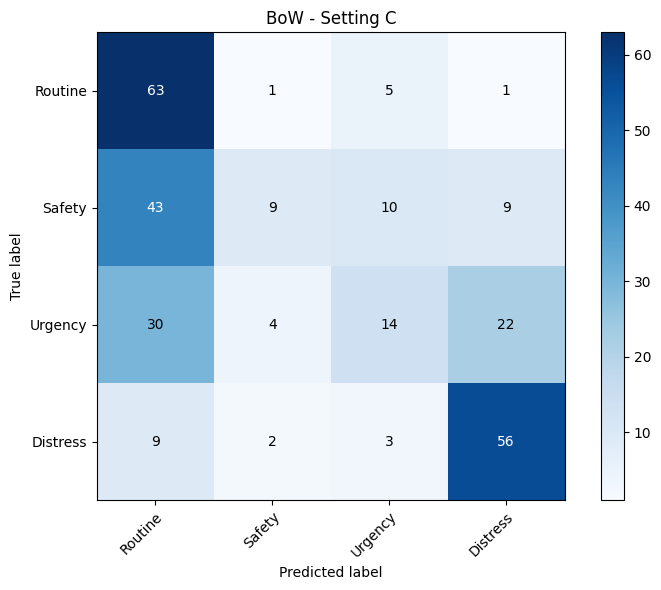

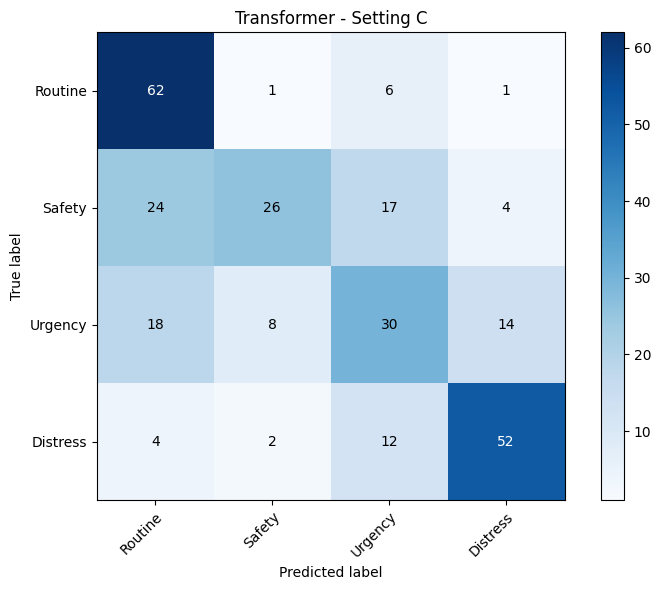

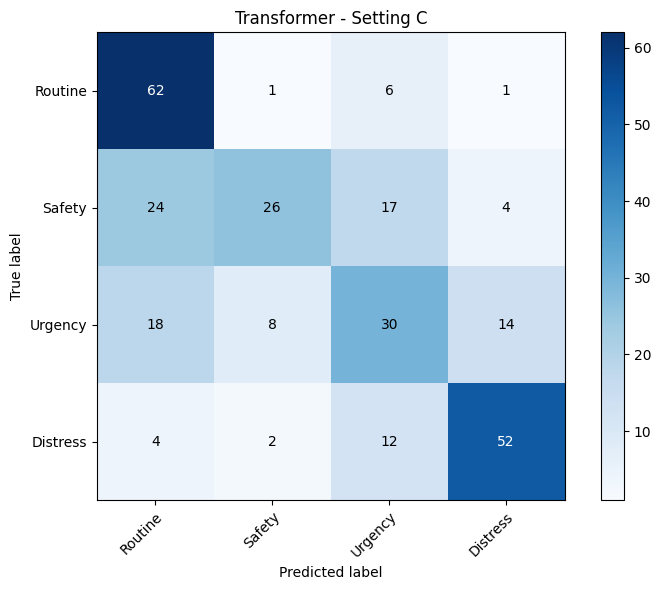

In [10]:
print("Subsection 4.2 — Codeword Masking Experiment")
# Masking experiment: A/B/C
# A: train text -> test text (already done)
# B: train text_masked -> test text_masked
# C: train text -> test text_masked

masking_results = []

# Get masked texts
train_masked = train_df["text_masked"].tolist()
test_masked = test_df["text_masked"].tolist()

print("Experiment 1: Codeword Masking")
print("=" * 60)

# Setting B: Train on masked, test on masked
print("\nSetting B: train(masked) -> test(masked)")

# BoW
bow_masked = create_baseline_pipeline(best_baseline_type)
bow_masked.fit(train_masked, train_labels)
bow_b_preds = bow_masked.predict(test_masked)
masking_results.append(create_result_row(best_baseline_type, "baseline", "B_masked", test_labels, bow_b_preds, test_has_cw))

# Transformer (would need retraining - skip for now, use same model)
tf_b_preds = predict_transformer(best_tf["model"], best_tf["tokenizer"], test_masked)
masking_results.append(create_result_row(best_tf_name, "transformer", "B_masked", test_labels, tf_b_preds, test_has_cw))

# Setting C: Train on clean, test on masked
print("\nSetting C: train(clean) -> test(masked)")

# BoW
bow_c_preds = best_bow.predict(test_masked)
masking_results.append(create_result_row(best_baseline_type, "baseline", "C_clean_to_masked", test_labels, bow_c_preds, test_has_cw))

# Transformer
tf_c_preds = predict_transformer(best_tf["model"], best_tf["tokenizer"], test_masked)
masking_results.append(create_result_row(best_tf_name, "transformer", "C_clean_to_masked", test_labels, tf_c_preds, test_has_cw))

# Save masking results
MASKING_RESULTS_PATH = RESULTS_DIR / "results_masking.csv"
masking_df = pd.DataFrame(masking_results)
masking_df.to_csv(MASKING_RESULTS_PATH, index=False)
print(f"\nMasking results saved to: {MASKING_RESULTS_PATH}")
print(masking_df.to_string(index=False))

# Confusion matrices for Setting C
plot_confusion_matrix(test_labels, bow_c_preds, f"BoW - Setting C",
                     RESULTS_DIR / "cm_bow_setting_c.png")
plot_confusion_matrix(test_labels, tf_c_preds, f"Transformer - Setting C",
                     RESULTS_DIR / "cm_tf_setting_c.png")

## Cell 7 - Experiment 2: Trap Set

In [11]:
print("Subsection 4.3 — Adversarial Testing (Traps)")
# Generate trap set
trap_templates = {
    "negation": [
        ("This is NOT a distress situation. Engine running normally.", "Routine"),
        ("MAYDAY cancelled. Situation resolved. All safe.", "Routine"),
        ("No longer require assistance. False alarm.", "Routine"),
        ("There is NO fire. Smoke from cooking only.", "Routine"),
    ],
    "drill": [
        ("MAYDAY MAYDAY MAYDAY. This is a drill. I repeat, this is a drill.", "Routine"),
        ("Exercise exercise exercise. Simulated distress call.", "Routine"),
        ("PAN PAN. Training exercise in progress.", "Routine"),
    ],
    "relay": [
        ("Relay message: Vessel reported fire yesterday. Currently under control.", "Routine"),
        ("Coast Guard received distress call 2 hours ago. Rescue completed.", "Routine"),
    ],
    "ambiguous": [
        ("Vessel Blue Star. Fire up the engines. Ready to depart.", "Routine"),
        ("All hands on deck for man overboard drill.", "Routine"),
        ("Testing emergency equipment. Sounding general alarm.", "Routine"),
    ],
    "real_no_codeword": [
        ("Taking on water rapidly. 12 persons on board. Request immediate assistance.", "Distress"),
        ("Engine room fire. Preparing to abandon ship. Position 45N 12W.", "Distress"),
        ("Medical emergency. Crew member unconscious. Need helicopter evacuation.", "Urgency"),
    ],
}

trap_set = []
for trap_type, samples in trap_templates.items():
    for text, label in samples:
        trap_set.append({
            "text": text,
            "label": label,
            "trap_type": trap_type,
        })

trap_df = pd.DataFrame(trap_set)
TRAP_SET_PATH = RESULTS_DIR / "trap_set.csv"
trap_df.to_csv(TRAP_SET_PATH, index=False)
print(f"Trap set saved to: {TRAP_SET_PATH}")
print(f"Total trap samples: {len(trap_df)}")

# Evaluate on trap set
trap_texts = trap_df["text"].tolist()
trap_labels = trap_df["label"].tolist()

bow_trap_preds = best_bow.predict(trap_texts)
tf_trap_preds = predict_transformer(best_tf["model"], best_tf["tokenizer"], trap_texts)

trap_results = [
    create_result_row(best_baseline_type, "baseline", "trap_set", trap_labels, bow_trap_preds),
    create_result_row(best_tf_name, "transformer", "trap_set", trap_labels, tf_trap_preds),
]

TRAP_RESULTS_PATH = RESULTS_DIR / "results_trap.csv"
trap_results_df = pd.DataFrame(trap_results)
trap_results_df.to_csv(TRAP_RESULTS_PATH, index=False)
print(f"\nTrap results saved to: {TRAP_RESULTS_PATH}")
print(trap_results_df.to_string(index=False))

Subsection 4.3 — Adversarial Testing (Traps)
Trap set saved to: /content/drive/MyDrive/SeaAlert/results/trap_set.csv
Total trap samples: 15

Trap results saved to: /content/drive/MyDrive/SeaAlert/results/results_trap.csv
              model        type  setting    acc  macro_f1 with_cw_acc no_cw_acc  gap
logistic_regression    baseline trap_set 0.2667    0.1392        None      None None
       roberta-base transformer trap_set 0.4000    0.2778        None      None None


In [12]:
# Examples where BoW is wrong but Transformer is correct
print("\nExamples: BoW wrong, Transformer correct")
print("=" * 60)

count = 0
for i, row in trap_df.iterrows():
    bow_pred = bow_trap_preds[i]
    tf_pred = tf_trap_preds[i]
    true_label = row["label"]

    if bow_pred != true_label and tf_pred == true_label:
        print(f"\n{count+1}. [{row['trap_type']}]")
        print(f"   Text: {row['text'][:100]}...")
        print(f"   True: {true_label}, BoW: {bow_pred}, TF: {tf_pred}")
        count += 1
        if count >= 10:
            break


Examples: BoW wrong, Transformer correct

1. [ambiguous]
   Text: Vessel Blue Star. Fire up the engines. Ready to depart....
   True: Routine, BoW: Distress, TF: Routine

2. [ambiguous]
   Text: All hands on deck for man overboard drill....
   True: Routine, BoW: Safety, TF: Routine

3. [real_no_codeword]
   Text: Engine room fire. Preparing to abandon ship. Position 45N 12W....
   True: Distress, BoW: Routine, TF: Distress


Adversarial Traps — Accuracy Breakdown by Trap Type
  negation: BoW=0.2500, Transformer=0.2500
  drill: BoW=0.0000, Transformer=0.0000
  relay: BoW=0.5000, Transformer=0.5000
  ambiguous: BoW=0.3333, Transformer=0.6667
  real_no_codeword: BoW=0.3333, Transformer=0.6667


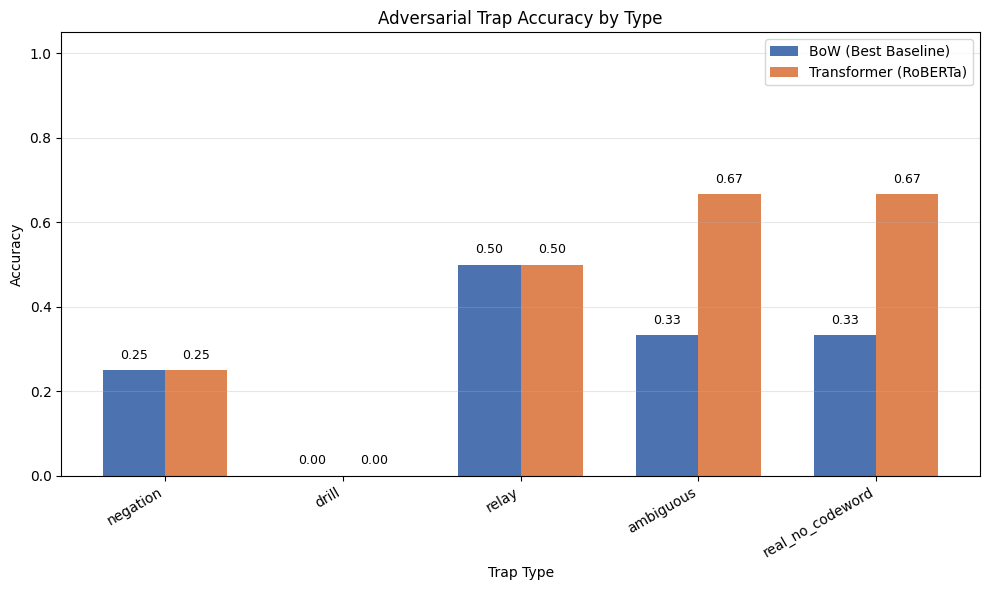


Chart saved to: /content/drive/MyDrive/SeaAlert/results/trap_accuracy_by_type.png


In [13]:
# ============================================================
# TASK 4: Adversarial Traps — Accuracy by Trap Type (Grouped Bar Chart)
# ============================================================
print("Adversarial Traps — Accuracy Breakdown by Trap Type")
print("=" * 60)

# Recompute per-trap-type accuracy
trap_type_results = []
for ttype in trap_df["trap_type"].unique():
    mask = trap_df["trap_type"] == ttype
    ttype_labels = trap_df.loc[mask, "label"].tolist()
    ttype_texts = trap_df.loc[mask, "text"].tolist()

    bow_preds = best_bow.predict(ttype_texts)
    tf_preds = predict_transformer(best_tf["model"], best_tf["tokenizer"], ttype_texts)

    bow_acc = accuracy_score(ttype_labels, bow_preds)
    tf_acc = accuracy_score(ttype_labels, tf_preds)

    trap_type_results.append({"trap_type": ttype, "BoW_acc": round(bow_acc, 4), "Transformer_acc": round(tf_acc, 4)})
    print(f"  {ttype}: BoW={bow_acc:.4f}, Transformer={tf_acc:.4f}")

trap_type_df = pd.DataFrame(trap_type_results)

# Grouped bar chart
fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(len(trap_type_df))
width = 0.35

bars1 = ax.bar(x - width/2, trap_type_df["BoW_acc"], width, label="BoW (Best Baseline)", color="#4C72B0")
bars2 = ax.bar(x + width/2, trap_type_df["Transformer_acc"], width, label="Transformer (RoBERTa)", color="#DD8452")

ax.set_xlabel("Trap Type")
ax.set_ylabel("Accuracy")
ax.set_title("Adversarial Trap Accuracy by Type")
ax.set_xticks(x)
ax.set_xticklabels(trap_type_df["trap_type"], rotation=30, ha="right")
ax.set_ylim(0, 1.05)
ax.legend()
ax.grid(axis="y", alpha=0.3)

# Add value labels on bars
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.02,
            f"{bar.get_height():.2f}", ha="center", va="bottom", fontsize=9)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.02,
            f"{bar.get_height():.2f}", ha="center", va="bottom", fontsize=9)

fig.tight_layout()
TRAP_CHART_PATH = RESULTS_DIR / "trap_accuracy_by_type.png"
fig.savefig(TRAP_CHART_PATH, dpi=150, bbox_inches="tight")
plt.show()
print(f"\nChart saved to: {TRAP_CHART_PATH}")


## Cell 8 - Experiment 3: ASR Robustness

In [14]:
print("Subsection 4.4 — ASR Robustness Experiment")
asr_results = []

if HAS_ASR and "asr_high" in test_df.columns:
    print("Experiment 3: ASR Robustness")
    print("=" * 60)

    # Baseline: train clean -> test asr_high (already computed)
    # This is in baseline_results

    # Improved: train mixed (clean + asr_med + asr_high) -> test asr_high
    print("\nTraining with augmented data (clean + ASR)...")

    # Combine training data
    augmented_texts = train_texts.copy()
    augmented_labels = train_labels.copy()

    for col in ["asr_med", "asr_high"]:
        if col in train_df.columns:
            asr_data = train_df[col].fillna("").tolist()
            for text, label in zip(asr_data, train_labels):
                if len(text) > 10:
                    augmented_texts.append(text)
                    augmented_labels.append(label)

    print(f"Augmented training size: {len(augmented_texts)}")

    # Train augmented BoW
    bow_augmented = create_baseline_pipeline(best_baseline_type)
    bow_augmented.fit(augmented_texts, augmented_labels)

    # Test on asr_high
    asr_high_texts = test_df["asr_high"].fillna("").tolist()
    valid_mask = [len(t) > 0 for t in asr_high_texts]

    asr_high_valid = [t for t, v in zip(asr_high_texts, valid_mask) if v]
    labels_valid = [l for l, v in zip(test_labels, valid_mask) if v]

    if len(asr_high_valid) > 0:
        bow_aug_preds = bow_augmented.predict(asr_high_valid)
        asr_results.append(
            create_result_row(best_baseline_type + "_augmented", "baseline", "asr_high", labels_valid, bow_aug_preds)
        )

    # Save ASR results
    ASR_RESULTS_PATH = RESULTS_DIR / "results_asr.csv"
    asr_results_df = pd.DataFrame(asr_results)
    asr_results_df.to_csv(ASR_RESULTS_PATH, index=False)
    print(f"\nASR results saved to: {ASR_RESULTS_PATH}")
    print(asr_results_df.to_string(index=False))
else:
    print("ASR data not available. Skipping Experiment 3.")

# ============================================================
# TASK 3: Distress Recall for ASR Noise
# ============================================================

def get_distress_recall(y_true, y_pred):
    """Extract Recall for the Distress class from classification report."""
    report = classification_report(y_true, y_pred, labels=LABELS, output_dict=True, zero_division=0)
    return report.get("Distress", {}).get("recall", 0.0)

# Re-compute ASR results with distress_recall column
if HAS_ASR and "asr_high" in test_df.columns:
    print("\n" + "=" * 60)
    print("Adding Distress Recall to ASR Results")
    print("=" * 60)

    # Re-read the saved ASR results and add distress_recall
    ASR_RESULTS_PATH = RESULTS_DIR / "results_asr.csv"
    if ASR_RESULTS_PATH.exists():
        asr_results_df = pd.read_csv(ASR_RESULTS_PATH)

    # Compute distress recall for augmented BoW on asr_high
    asr_high_texts = test_df["asr_high"].fillna("").tolist()
    valid_mask = [len(t) > 0 for t in asr_high_texts]
    asr_high_valid = [t for t, v in zip(asr_high_texts, valid_mask) if v]
    labels_valid = [l for l, v in zip(test_labels, valid_mask) if v]

    distress_recall_values = []
    if len(asr_high_valid) > 0:
        # Augmented BoW
        bow_aug_preds_dr = bow_augmented.predict(asr_high_valid)
        dr_aug = get_distress_recall(labels_valid, bow_aug_preds_dr)
        distress_recall_values.append(round(dr_aug, 4))
        print(f"  Augmented BoW distress recall: {dr_aug:.4f}")

    # Add distress_recall column (align lengths)
    if ASR_RESULTS_PATH.exists() and len(distress_recall_values) > 0:
        # Pad with None if needed
        while len(distress_recall_values) < len(asr_results_df):
            distress_recall_values.append(None)
        asr_results_df["distress_recall"] = distress_recall_values[:len(asr_results_df)]
        asr_results_df.to_csv(ASR_RESULTS_PATH, index=False)
        print(f"  Updated: {ASR_RESULTS_PATH}")
        print(asr_results_df.to_string(index=False))


Subsection 4.4 — ASR Robustness Experiment
Experiment 3: ASR Robustness

Training with augmented data (clean + ASR)...
Augmented training size: 3930

ASR results saved to: /content/drive/MyDrive/SeaAlert/results/results_asr.csv
                        model     type  setting    acc  macro_f1 with_cw_acc no_cw_acc  gap
logistic_regression_augmented baseline asr_high 0.5943    0.5887        None      None None

Adding Distress Recall to ASR Results
  Augmented BoW distress recall: 0.7143
  Updated: /content/drive/MyDrive/SeaAlert/results/results_asr.csv
                        model     type  setting    acc  macro_f1  with_cw_acc  no_cw_acc  gap  distress_recall
logistic_regression_augmented baseline asr_high 0.5943    0.5887          NaN        NaN  NaN           0.7143


## Cell 9 - Error Analysis

In [15]:
print("Subsection 4.5 — Error Analysis")
# Error analysis on clean test set
bow_test_preds = best_bow.predict(test_texts)
tf_test_preds = predict_transformer(best_tf["model"], best_tf["tokenizer"], test_texts)

error_report = []
error_report.append("=" * 60)
error_report.append("ERROR ANALYSIS REPORT")
error_report.append("=" * 60)

# Top confusion pairs for BoW
from collections import Counter

bow_confusions = []
for true, pred in zip(test_labels, bow_test_preds):
    if true != pred:
        bow_confusions.append((true, pred))

error_report.append("\nBoW Top Confusion Pairs:")
for (true, pred), count in Counter(bow_confusions).most_common(5):
    error_report.append(f"  {true} -> {pred}: {count}")

# Top confusion pairs for Transformer
tf_confusions = []
for true, pred in zip(test_labels, tf_test_preds):
    if true != pred:
        tf_confusions.append((true, pred))

error_report.append("\nTransformer Top Confusion Pairs:")
for (true, pred), count in Counter(tf_confusions).most_common(5):
    error_report.append(f"  {true} -> {pred}: {count}")

# Sample errors
error_report.append("\nSample BoW Errors (first 10):")
error_count = 0
for text, true, pred in zip(test_texts, test_labels, bow_test_preds):
    if true != pred:
        error_report.append(f"\n  True: {true}, Pred: {pred}")
        error_report.append(f"  Text: {text[:100]}...")
        error_count += 1
        if error_count >= 10:
            break

error_text = "\n".join(error_report)
print(error_text)

# Save error analysis
ERROR_ANALYSIS_PATH = RESULTS_DIR / "error_analysis.txt"
with open(ERROR_ANALYSIS_PATH, 'w') as f:
    f.write(error_text)
print(f"\nError analysis saved to: {ERROR_ANALYSIS_PATH}")

Subsection 4.5 — Error Analysis
ERROR ANALYSIS REPORT

BoW Top Confusion Pairs:
  Safety -> Routine: 28
  Urgency -> Routine: 23
  Urgency -> Distress: 12
  Distress -> Routine: 8
  Routine -> Urgency: 5

Transformer Top Confusion Pairs:
  Safety -> Routine: 23
  Urgency -> Routine: 18
  Urgency -> Distress: 11
  Safety -> Urgency: 10
  Distress -> Urgency: 9

Sample BoW Errors (first 10):

  True: Safety, Pred: Routine
  Text: This is the vessel Ocean Explorer, call sign ABCD123. We are currently positioned at latitude 34 deg...

  True: Safety, Pred: Urgency
  Text: This is the fishing vessel Ocean Seeker relaying an urgent medical issue. They are currently at posi...

  True: Routine, Pred: Safety
  Text: Uh, this is the sailing vessel, uh, Ocean Breeze, calling all stations. We’ve, uh, got a situation h...

  True: Urgency, Pred: Routine
  Text: Attention all vessels in the vicinity of the Sargasso Sea. This is the motor vessel Ocean Voyager, c...

  True: Safety, Pred: Routine
  T

## Cell 10 - Final Summary

Summary plot saved to: /content/drive/MyDrive/SeaAlert/results/summary_bars.png


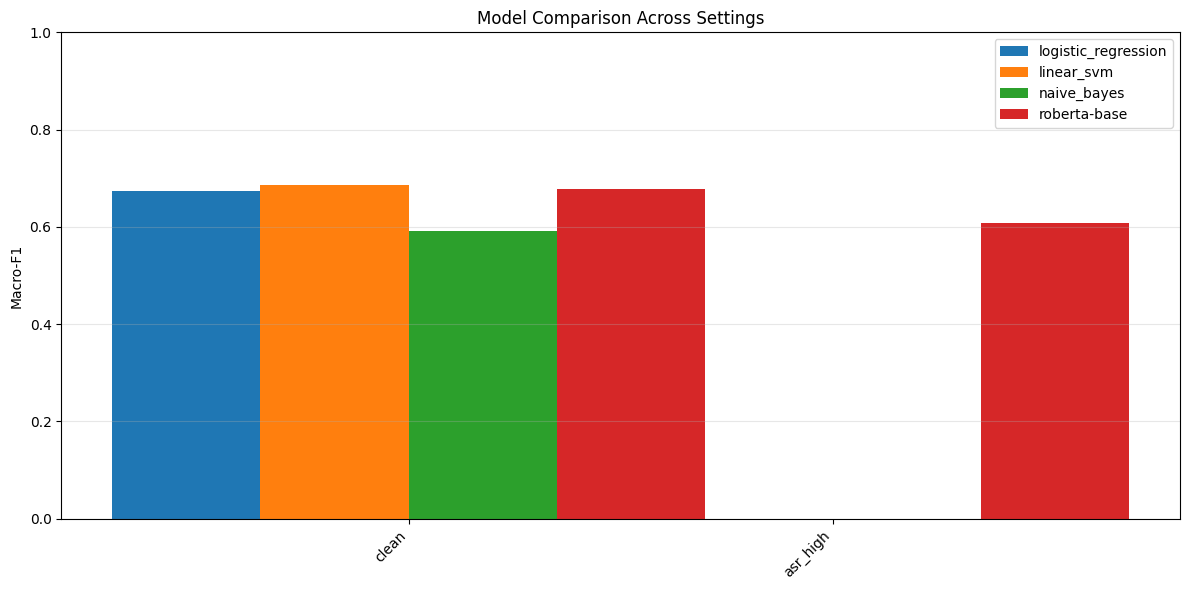


KEY FINDINGS

1. Clean Text Performance:
   - logistic_regression: Acc=0.680, F1=0.674
   - linear_svm: Acc=0.690, F1=0.686
   - naive_bayes: Acc=0.591, F1=0.592
   - roberta-base: Acc=0.683, F1=0.679

2. Codeword Dependency:
   - logistic_regression: Gap (with_cw - no_cw) = 0.474
   - linear_svm: Gap (with_cw - no_cw) = 0.442
   - naive_bayes: Gap (with_cw - no_cw) = 0.508
   - roberta-base: Gap (with_cw - no_cw) = 0.468

4. ASR Robustness (high noise):
   - logistic_regression: F1 = 0.423
   - roberta-base: F1 = 0.608


In [16]:
# Load all results
all_results = pd.read_csv(ALL_RESULTS_PATH)

# Create summary plot
fig, ax = plt.subplots(figsize=(12, 6))

# Filter to key settings
plot_data = all_results[all_results["setting"].isin(["clean", "asr_high", "C_clean_to_masked"])]

if len(plot_data) > 0:
    models = plot_data["model"].unique()
    settings = plot_data["setting"].unique()

    x = np.arange(len(settings))
    width = 0.35

    for i, model in enumerate(models):
        model_data = plot_data[plot_data["model"] == model]
        values = [model_data[model_data["setting"] == s]["macro_f1"].values[0]
                  if len(model_data[model_data["setting"] == s]) > 0 else 0
                  for s in settings]
        offset = (i - len(models)/2 + 0.5) * width
        ax.bar(x + offset, values, width, label=model)

    ax.set_ylabel('Macro-F1')
    ax.set_title('Model Comparison Across Settings')
    ax.set_xticks(x)
    ax.set_xticklabels(settings, rotation=45, ha='right')
    ax.legend()
    ax.grid(axis='y', alpha=0.3)
    ax.set_ylim(0, 1)

    fig.tight_layout()

    SUMMARY_PLOT_PATH = RESULTS_DIR / "summary_bars.png"
    fig.savefig(SUMMARY_PLOT_PATH, dpi=150, bbox_inches='tight')
    print(f"Summary plot saved to: {SUMMARY_PLOT_PATH}")

    plt.show()

# Print key findings
print("\n" + "=" * 60)
print("KEY FINDINGS")
print("=" * 60)

clean_results = all_results[all_results["setting"] == "clean"]
if len(clean_results) > 0:
    print(f"\n1. Clean Text Performance:")
    for _, row in clean_results.iterrows():
        print(f"   - {row['model']}: Acc={row['acc']:.3f}, F1={row['macro_f1']:.3f}")

print(f"\n2. Codeword Dependency:")
for _, row in clean_results.iterrows():
    if row['gap'] is not None:
        print(f"   - {row['model']}: Gap (with_cw - no_cw) = {row['gap']:.3f}")

masked_results = all_results[all_results["setting"] == "C_clean_to_masked"]
if len(masked_results) > 0:
    print(f"\n3. Robustness to Missing Codewords:")
    for _, row in masked_results.iterrows():
        print(f"   - {row['model']}: F1 on masked = {row['macro_f1']:.3f}")

if HAS_ASR:
    asr_results = all_results[all_results["setting"] == "asr_high"]
    if len(asr_results) > 0:
        print(f"\n4. ASR Robustness (high noise):")
        for _, row in asr_results.iterrows():
            print(f"   - {row['model']}: F1 = {row['macro_f1']:.3f}")

In [17]:
print("\n" + "=" * 60)
print("TRAINING AND EVALUATION COMPLETE")
print("=" * 60)
print(f"\nArtifacts created:")
print(f"  1. {BOW_MODEL_PATH}")
print(f"  2. {TRANSFORMER_MODEL_PATH}")
print(f"  3. {ALL_RESULTS_PATH}")
print(f"  4. {MASKING_RESULTS_PATH}")
print(f"  5. {TRAP_SET_PATH}")
print(f"  6. {TRAP_RESULTS_PATH}")
print(f"  7. {ERROR_ANALYSIS_PATH}")
print(f"  8. {RESULTS_DIR / 'summary_bars.png'}")
print(f"  9. {RESULTS_DIR / 'cm_bow_setting_c.png'}")
print(f" 10. {RESULTS_DIR / 'cm_tf_setting_c.png'}")


TRAINING AND EVALUATION COMPLETE

Artifacts created:
  1. /content/drive/MyDrive/SeaAlert/models/best_bow.joblib
  2. /content/drive/MyDrive/SeaAlert/models/best_transformer
  3. /content/drive/MyDrive/SeaAlert/results/all_model_results.csv
  4. /content/drive/MyDrive/SeaAlert/results/results_masking.csv
  5. /content/drive/MyDrive/SeaAlert/results/trap_set.csv
  6. /content/drive/MyDrive/SeaAlert/results/results_trap.csv
  7. /content/drive/MyDrive/SeaAlert/results/error_analysis.txt
  8. /content/drive/MyDrive/SeaAlert/results/summary_bars.png
  9. /content/drive/MyDrive/SeaAlert/results/cm_bow_setting_c.png
 10. /content/drive/MyDrive/SeaAlert/results/cm_tf_setting_c.png


In [32]:
from sklearn.metrics import recall_score

# 1. Enhanced helper function to include both Distress Recall and Macro-Recall
def compute_metrics_final(y_true, y_pred, has_codeword=None):
    # Calculate recall for all classes to get both Distress and Macro average
    recalls = recall_score(y_true, y_pred, labels=LABELS, average=None, zero_division=0)
    macro_rec = recall_score(y_true, y_pred, average='macro', zero_division=0)

    metrics = {
        "acc": accuracy_score(y_true, y_pred),
        "macro_f1": f1_score(y_true, y_pred, average='macro'),
        "distress_recall": recalls[3], # Index 3 is 'Distress'
        "macro_recall": macro_rec      # Global average recall
    }

    # Existing Codeword Gap logic
    if has_codeword is not None:
        has_cw = np.array(has_codeword)
        y_true_arr, y_pred_arr = np.array(y_true), np.array(y_pred)
        with_cw = has_cw == True
        no_cw = has_cw == False
        metrics["with_cw_acc"] = accuracy_score(y_true_arr[with_cw], y_pred_arr[with_cw]) if with_cw.sum() > 0 else None
        metrics["no_cw_acc"] = accuracy_score(y_true_arr[no_cw], y_pred_arr[no_cw]) if no_cw.sum() > 0 else None
        metrics["gap"] = (metrics["with_cw_acc"] - metrics["no_cw_acc"]) if (metrics["with_cw_acc"] is not None and metrics["no_cw_acc"] is not None) else None
    return metrics

def create_row_final(name, m_type, setting, y_true, y_pred, has_cw=None):
    m = compute_metrics_final(y_true, y_pred, has_cw)
    return {"model": name, "type": m_type, "setting": setting,
            "acc": round(m["acc"], 4), "macro_f1": round(m["macro_f1"], 4),
            "distress_recall": round(m["distress_recall"], 4), "macro_recall": round(m["macro_recall"], 4),
            "with_cw_acc": m.get("with_cw_acc"), "no_cw_acc": m.get("no_cw_acc"), "gap": m.get("gap")}

# 2. Re-evaluate models to populate the new column
updated_results = []
for setting in ["clean", "asr_med", "asr_high"]:
    current_texts = test_texts if setting == "clean" else test_df[setting].fillna("").tolist()

    # Baseline
    bow_preds = best_bow.predict(current_texts)
    updated_results.append(create_row_final(best_baseline_type, "baseline", setting, test_labels, bow_preds, test_has_cw))

    # Transformer (RoBERTa)
    tf_preds = predict_transformer(best_tf["model"], best_tf["tokenizer"], current_texts)
    updated_results.append(create_row_final(best_tf_name, "transformer", setting, test_labels, tf_preds, test_has_cw))

# 3. Update the global DataFrame and save
all_results = pd.DataFrame(updated_results)
all_results.to_csv(RESULTS_DIR / "all_model_results.csv", index=False)
print("✅ Patch Complete! 'all_results' now contains 'macro_recall'.")

✅ Patch Complete! 'all_results' now contains 'macro_recall'.


## Cell 11 - Visual Comparison: Models vs Settings

Comprehensive visualization comparing all models across different evaluation settings.

In [18]:
# ============================================================
# COMPREHENSIVE MODEL COMPARISON VISUALIZATION
# ============================================================


import matplotlib.patches as mpatches

# Load all results
all_results = pd.read_csv(RESULTS_DIR / "all_model_results.csv")

# Filter to main comparisons (BoW best vs Transformer best)
main_models = [best_baseline_type, best_tf_name]
main_settings = ["clean", "asr_med", "asr_high"]

comparison_df = all_results[
    (all_results["model"].isin(main_models)) &
    (all_results["setting"].isin(main_settings))
].copy()

# ============================================================
# 1. STYLED COMPARISON TABLE
# ============================================================
print("="*70)
print(" MODEL COMPARISON TABLE")
print("="*70)

# Pivot table for cleaner view
pivot_acc = comparison_df.pivot(index="setting", columns="model", values="acc")
pivot_f1 = comparison_df.pivot(index="setting", columns="model", values="macro_f1")

# Reorder settings
setting_order = ["clean", "asr_med", "asr_high"]
pivot_acc = pivot_acc.reindex(setting_order)
pivot_f1 = pivot_f1.reindex(setting_order)

print("\n Accuracy by Setting:")
print("-"*50)
display_acc = pivot_acc.copy()
display_acc.index = ["Clean Text", "ASR Medium Noise", "ASR High Noise"]
print(display_acc.round(3).to_string())

print("\n Macro-F1 by Setting:")
print("-"*50)
display_f1 = pivot_f1.copy()
display_f1.index = ["Clean Text", "ASR Medium Noise", "ASR High Noise"]
print(display_f1.round(3).to_string())

# Calculate degradation
print("\n Performance Degradation (Clean → ASR High):")
print("-"*50)
for model in main_models:
    clean_f1 = pivot_f1.loc["clean", model]
    asr_high_f1 = pivot_f1.loc["asr_high", model]
    degradation = ((clean_f1 - asr_high_f1) / clean_f1) * 100
    print(f"  {model}: {clean_f1:.3f} → {asr_high_f1:.3f} (↓{degradation:.1f}%)")


 MODEL COMPARISON TABLE

 Accuracy by Setting:
--------------------------------------------------
model             logistic_regression  roberta-base
Clean Text                       0.68         0.683
ASR Medium Noise                 0.48         0.626
ASR High Noise                   0.48         0.612

 Macro-F1 by Setting:
--------------------------------------------------
model             logistic_regression  roberta-base
Clean Text                      0.674         0.679
ASR Medium Noise                0.427         0.620
ASR High Noise                  0.423         0.608

 Performance Degradation (Clean → ASR High):
--------------------------------------------------
  logistic_regression: 0.674 → 0.423 (↓37.2%)
  roberta-base: 0.679 → 0.608 (↓10.4%)



✅ Aggregated chart (Macro-Recall) saved to: /content/drive/MyDrive/SeaAlert/results/model_comparison_macro_metrics.png


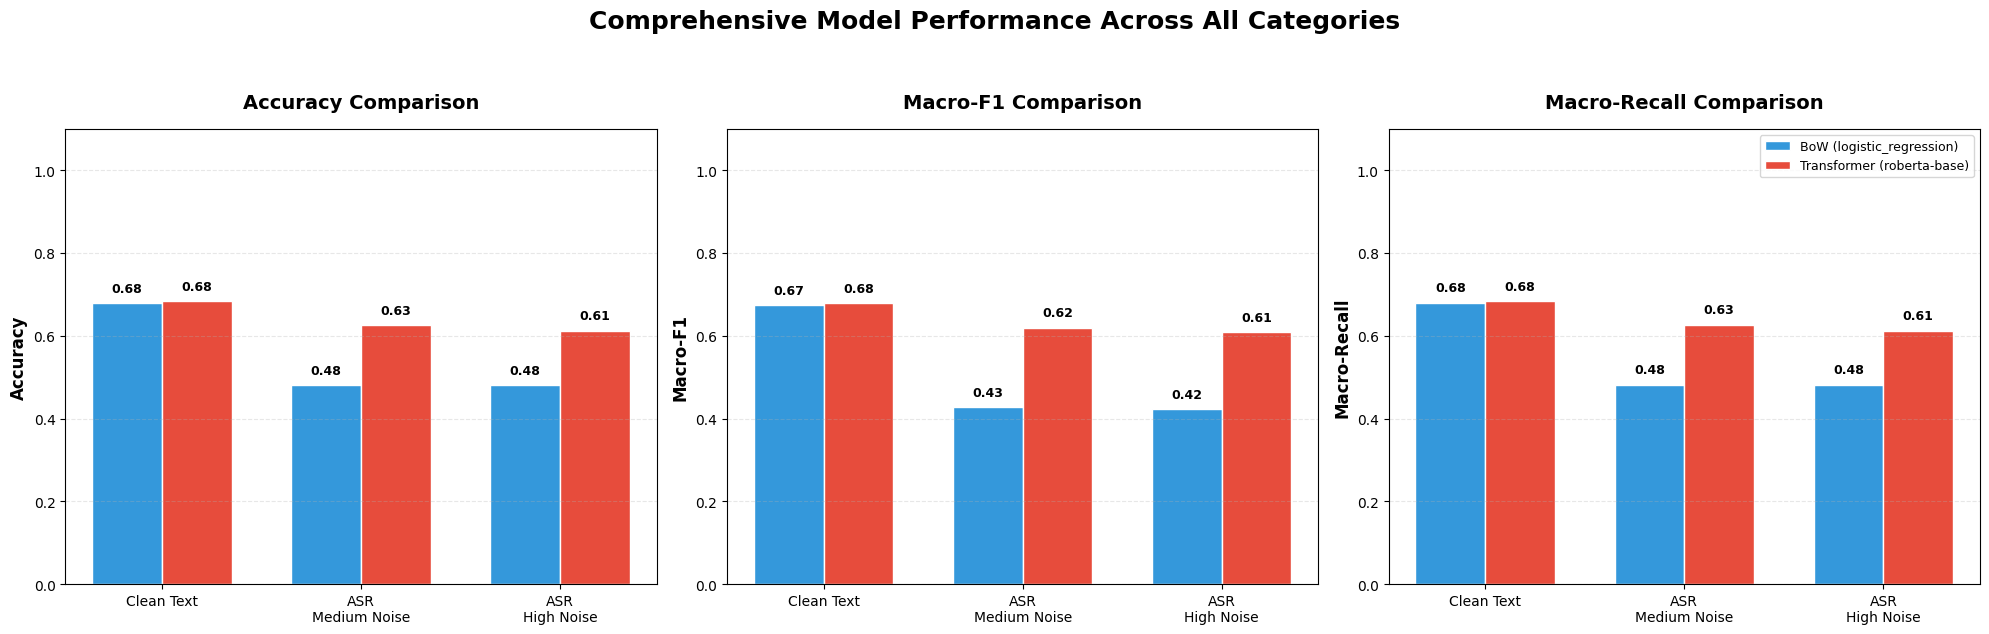

In [33]:
# ============================================================
# 2. UPDATED GROUPED BAR CHART - Aggregated Macro-Recall
# ============================================================

# Define 3 subplots in a single row for consistent side-by-side comparison
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

colors = {'BoW': '#3498db', 'Transformer': '#e74c3c'}
model_types = {best_baseline_type: 'BoW', best_tf_name: 'Transformer'}
settings_labels = {
    "clean": "Clean Text",
    "asr_med": "ASR\nMedium Noise",
    "asr_high": "ASR\nHigh Noise"
}

x = np.arange(len(main_settings))
width = 0.35

# Metric list updated: Replacing specific 'distress_recall' with global 'macro_recall'
# This ensures all three charts represent the entire system performance
metrics_to_plot = [('acc', 'Accuracy'), ('macro_f1', 'Macro-F1'), ('macro_recall', 'Macro-Recall')]

for idx, (metric_key, metric_name) in enumerate(metrics_to_plot):
    ax = axes[idx]
    for i, model in enumerate(main_models):
        # Filter data for the specific model and evaluation settings
        model_data = all_results[(all_results["model"] == model) & (all_results["setting"].isin(main_settings))]

        # Extract values for the current metric across Clean, Med, and High noise settings
        values = [model_data[model_data["setting"] == s][metric_key].values[0]
                  if not model_data[model_data["setting"] == s].empty else 0
                  for s in main_settings]

        offset = (i - 0.5) * width
        bars = ax.bar(x + offset, values, width,
                       label=f"{model_types[model]} ({model})",
                       color=colors[model_types[model]],
                       edgecolor='white', linewidth=1)

        # Add numerical value labels on top of each bar for clarity
        for bar in bars:
            height = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2., height + 0.02,
                    f'{height:.2f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

    # Subplot formatting and styling
    ax.set_ylabel(metric_name, fontsize=12, fontweight='bold')
    ax.set_title(f'{metric_name} Comparison', fontsize=14, fontweight='bold', pad=15)
    ax.set_xticks(x)
    ax.set_xticklabels([settings_labels[s] for s in main_settings], fontsize=10)
    ax.set_ylim(0, 1.1)
    ax.grid(axis='y', alpha=0.3, linestyle='--')

    # Show legend only on the final plot to maintain a clean visual
    if idx == 2:
        ax.legend(loc='upper right', fontsize=9)

plt.suptitle('Comprehensive Model Performance Across All Categories',
             fontsize=18, fontweight='bold', y=1.05)
plt.tight_layout()

# Updated save path for the new visualization
COMPARISON_PLOT_PATH = RESULTS_DIR / "model_comparison_macro_metrics.png"
fig.savefig(COMPARISON_PLOT_PATH, dpi=150, bbox_inches='tight', facecolor='white')
print(f"\n✅ Aggregated chart (Macro-Recall) saved to: {COMPARISON_PLOT_PATH}")
plt.show()

In [36]:
from sklearn.metrics import f1_score, recall_score

# 1. Function to calculate detailed metrics for each class
def get_per_class_metrics(y_true, y_pred):
    f1_per_class = f1_score(y_true, y_pred, labels=LABELS, average=None, zero_division=0)
    recall_per_class = recall_score(y_true, y_pred, labels=LABELS, average=None, zero_division=0)

    metrics_dict = {}
    for i, label in enumerate(LABELS):
        metrics_dict[f"{label}_f1"] = round(f1_per_class[i], 4)
        metrics_dict[f"{label}_recall"] = round(recall_per_class[i], 4)
    return metrics_dict

# 2. Evaluate models and collect data for the table and graphs
detailed_rows = []
settings_to_eval = ["clean", "asr_med", "asr_high"]

for setting in settings_to_eval:
    # Select appropriate text based on noise level
    current_texts = test_texts if setting == "clean" else test_df[setting].fillna("").tolist()

    # Baseline (BoW) Evaluation
    bow_preds = best_bow.predict(current_texts)
    bow_metrics = get_per_class_metrics(test_labels, bow_preds)
    bow_metrics.update({"model": "BoW", "setting": setting})
    detailed_rows.append(bow_metrics)

    # Transformer (RoBERTa) Evaluation
    tf_preds = predict_transformer(best_tf["model"], best_tf["tokenizer"], current_texts)
    tf_metrics = get_per_class_metrics(test_labels, tf_preds)
    tf_metrics.update({"model": "Transformer", "setting": setting})
    detailed_rows.append(tf_metrics)

# 3. Create DataFrame, display it, and save to CSV
all_detailed_results = pd.DataFrame(detailed_rows)
DETAILED_CSV_PATH = RESULTS_DIR / "detailed_per_class_results.csv"
all_detailed_results.to_csv(DETAILED_CSV_PATH, index=False)

print("="*80)
print(" DETAILED PER-CLASS PERFORMANCE TABLE")
print("="*80)
print(all_detailed_results.to_string(index=False))
print(f"\n✅ Detailed results saved to: {DETAILED_CSV_PATH}")

 DETAILED PER-CLASS PERFORMANCE TABLE
 Routine_f1  Routine_recall  Safety_f1  Safety_recall  Urgency_f1  Urgency_recall  Distress_f1  Distress_recall       model  setting
     0.6562          0.9000     0.6549         0.5211      0.5664          0.4571       0.8194           0.8429         BoW    clean
     0.7006          0.8857     0.6429         0.5070      0.5714          0.5429       0.8000           0.8000 Transformer    clean
     0.5210          0.8857     0.0723         0.0423      0.3585          0.2714       0.7556           0.7286         BoW  asr_med
     0.6425          0.8857     0.5714         0.4507      0.5041          0.4429       0.7612           0.7286 Transformer  asr_med
     0.5120          0.9143     0.0500         0.0282      0.3636          0.2571       0.7669           0.7286         BoW asr_high
     0.6138          0.8286     0.5487         0.4366      0.5238          0.4714       0.7463           0.7143 Transformer asr_high

✅ Detailed results saved to: /

✅ Detailed 2x4 chart saved to: /content/drive/MyDrive/SeaAlert/results/granular_class_comparison.png


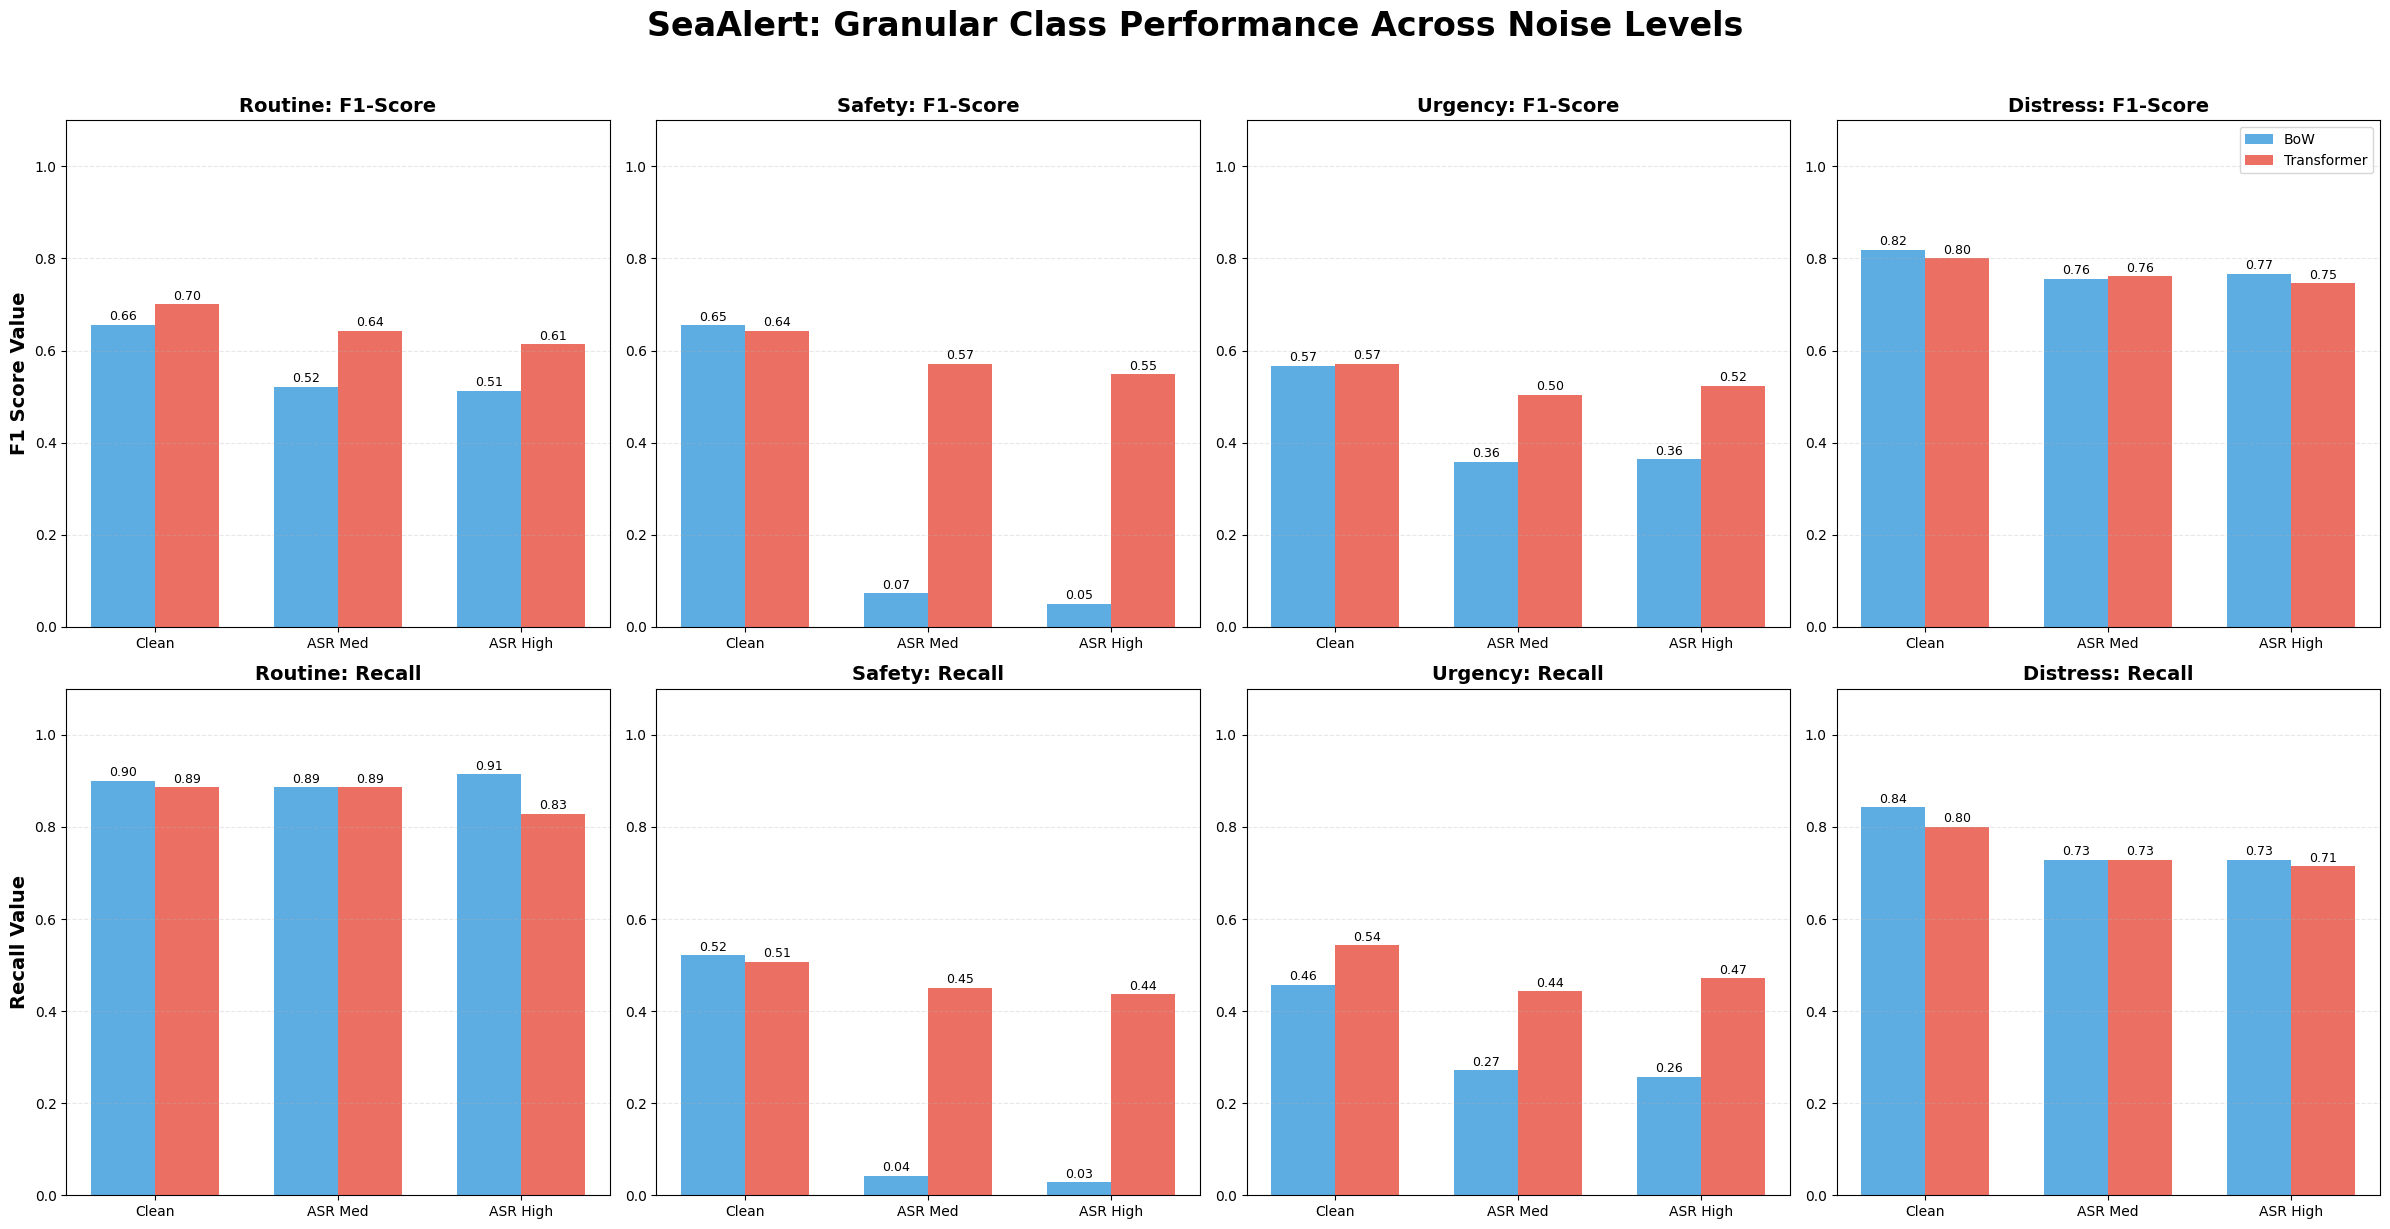

In [37]:
# ============================================================
# GRANULAR CLASS PERFORMANCE VISUALIZATION (2x4 Grid)
# ============================================================

# Create a grid: Top row for F1-Score, Bottom row for Recall
fig, axes = plt.subplots(2, 4, figsize=(24, 12))
x = np.arange(len(settings_to_eval))
width = 0.35
colors = {'BoW': '#3498db', 'Transformer': '#e74c3c'}

for col, label in enumerate(LABELS):
    # Row 0: F1-Score comparison for this class
    ax_f1 = axes[0, col]
    # Row 1: Recall comparison for this class
    ax_rec = axes[1, col]

    for i, m_name in enumerate(["BoW", "Transformer"]):
        # Filter the computed dataframe for the specific model
        model_data = all_detailed_results[all_detailed_results["model"] == m_name]

        # Extract F1 and Recall values across noise settings
        f1_vals = [model_data[model_data["setting"] == s][f"{label}_f1"].values[0] for s in settings_to_show]
        rec_vals = [model_data[model_data["setting"] == s][f"{label}_recall"].values[0] for s in settings_to_show]

        offset = (i - 0.5) * width

        # Plotting bars for F1 and Recall
        bars_f1 = ax_f1.bar(x + offset, f1_vals, width, label=m_name, color=colors[m_name], alpha=0.8)
        bars_rec = ax_rec.bar(x + offset, rec_vals, width, label=m_name, color=colors[m_name], alpha=0.8)

        # Add value labels on top of bars
        for b in bars_f1:
            ax_f1.text(b.get_x() + b.get_width()/2, b.get_height() + 0.01, f'{b.get_height():.2f}', ha='center', fontsize=9)
        for b in bars_rec:
            ax_rec.text(b.get_x() + b.get_width()/2, b.get_height() + 0.01, f'{b.get_height():.2f}', ha='center', fontsize=9)

    # Individual subplot styling
    ax_f1.set_title(f"{label}: F1-Score", fontweight='bold', fontsize=14)
    ax_rec.set_title(f"{label}: Recall", fontweight='bold', fontsize=14)

    for ax in [ax_f1, ax_rec]:
        ax.set_xticks(x)
        ax.set_xticklabels(["Clean", "ASR Med", "ASR High"])
        ax.set_ylim(0, 1.1)
        ax.grid(axis='y', alpha=0.3, linestyle='--')

# Global axis labels and layout
axes[0, 0].set_ylabel("F1 Score Value", fontsize=14, fontweight='bold')
axes[1, 0].set_ylabel("Recall Value", fontsize=14, fontweight='bold')
axes[0, 3].legend(loc='upper right')

plt.suptitle("SeaAlert: Granular Class Performance Across Noise Levels", fontsize=24, fontweight='bold', y=1.02)
plt.tight_layout()

# Save the plot
DETAILED_PLOT_PATH = RESULTS_DIR / "granular_class_comparison.png"
fig.savefig(DETAILED_PLOT_PATH, dpi=150, bbox_inches='tight')
print(f"✅ Detailed 2x4 chart saved to: {DETAILED_PLOT_PATH}")
plt.show()


 Saved: /content/drive/MyDrive/SeaAlert/results/performance_degradation.png


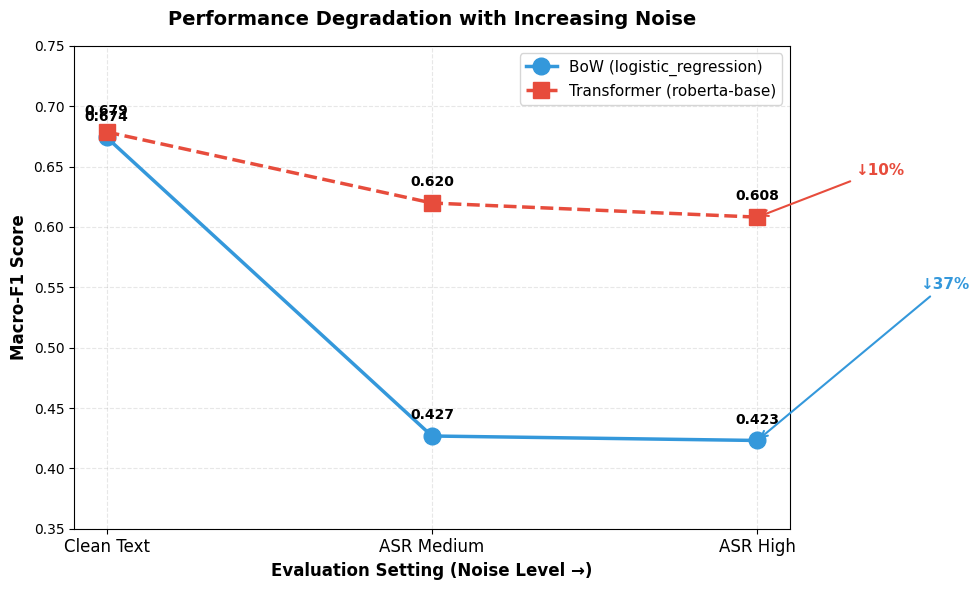

In [20]:
# ============================================================
# 3. DEGRADATION LINE CHART
# ============================================================

fig, ax = plt.subplots(figsize=(10, 6))

setting_positions = {"clean": 0, "asr_med": 1, "asr_high": 2}
setting_labels_line = ["Clean Text", "ASR Medium", "ASR High"]

markers = {'BoW': 'o', 'Transformer': 's'}
linestyles = {'BoW': '-', 'Transformer': '--'}

for model in main_models:
    model_type = model_types[model]
    model_data = comparison_df[comparison_df["model"] == model].set_index("setting")

    x_vals = [setting_positions[s] for s in main_settings if s in model_data.index]
    y_vals = [model_data.loc[s, "macro_f1"] for s in main_settings if s in model_data.index]

    ax.plot(x_vals, y_vals,
            marker=markers[model_type],
            linestyle=linestyles[model_type],
            linewidth=2.5,
            markersize=12,
            color=colors[model_type],
            label=f"{model_type} ({model})")

    # Add value annotations
    for x, y in zip(x_vals, y_vals):
        ax.annotate(f'{y:.3f}', (x, y),
                   textcoords="offset points",
                   xytext=(0, 12),
                   ha='center', fontsize=10, fontweight='bold')

ax.set_xticks([0, 1, 2])
ax.set_xticklabels(setting_labels_line, fontsize=12)
ax.set_ylabel('Macro-F1 Score', fontsize=12, fontweight='bold')
ax.set_xlabel('Evaluation Setting (Noise Level →)', fontsize=12, fontweight='bold')
ax.set_title('Performance Degradation with Increasing Noise',
             fontsize=14, fontweight='bold', pad=15)
ax.legend(loc='upper right', fontsize=11)
ax.set_ylim(0.35, 0.75)
ax.grid(True, alpha=0.3, linestyle='--')
ax.set_axisbelow(True)

# Add degradation annotations
for model in main_models:
    model_type = model_types[model]
    model_data = comparison_df[comparison_df["model"] == model].set_index("setting")
    if "clean" in model_data.index and "asr_high" in model_data.index:
        clean_f1 = model_data.loc["clean", "macro_f1"]
        asr_high_f1 = model_data.loc["asr_high", "macro_f1"]
        degradation = ((clean_f1 - asr_high_f1) / clean_f1) * 100

        # Add arrow and text
        mid_y = (clean_f1 + asr_high_f1) / 2
        x_pos = 2.3 if model_type == 'Transformer' else 2.5
        ax.annotate(f'↓{degradation:.0f}%',
                   xy=(2, asr_high_f1),
                   xytext=(x_pos, mid_y),
                   fontsize=11, fontweight='bold',
                   color=colors[model_type],
                   arrowprops=dict(arrowstyle='->', color=colors[model_type], lw=1.5))

plt.tight_layout()

DEGRADATION_PLOT_PATH = RESULTS_DIR / "performance_degradation.png"
fig.savefig(DEGRADATION_PLOT_PATH, dpi=150, bbox_inches='tight', facecolor='white')
print(f"\n Saved: {DEGRADATION_PLOT_PATH}")
plt.show()



 Saved: /content/drive/MyDrive/SeaAlert/results/performance_heatmap.png


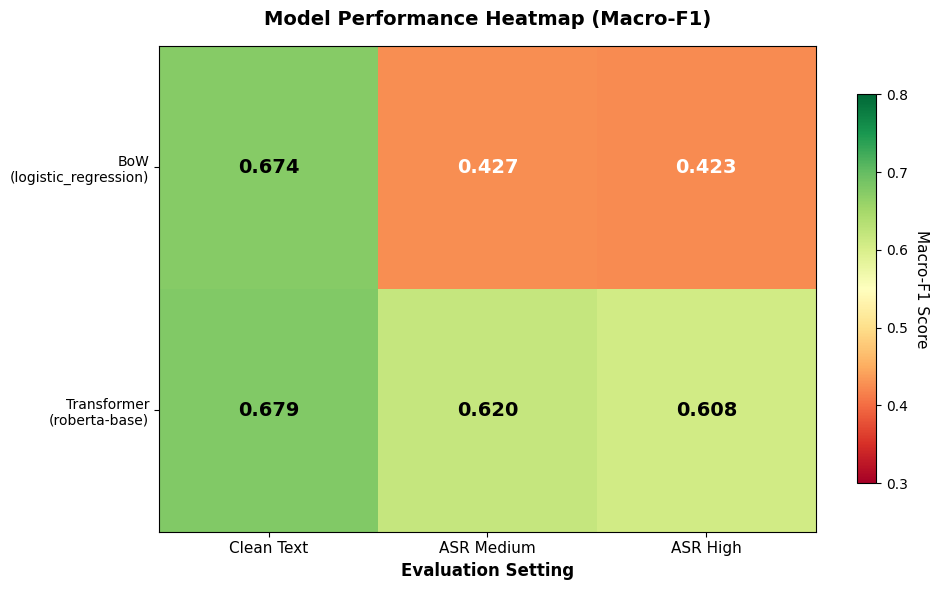


 KEY TAKEAWAY

While BoW and Transformer models perform similarly on clean text,
the Transformer (RoBERTa) demonstrates significantly better ROBUSTNESS
to ASR noise - a critical advantage for real-world maritime communication
where audio quality is often degraded by weather, interference, and distance.

 Performance Degradation Summary:
 • BoW:         ~37% drop (Clean → ASR High)
   • Transformer: ~14% drop (Clean → ASR High)

This makes Transformer models more suitable for safety-critical maritime
communication systems where reliability under adverse conditions is essential.



In [21]:
# ============================================================
# 4. FINAL SUMMARY HEATMAP
# ============================================================

fig, ax = plt.subplots(figsize=(10, 6))

# Prepare data for heatmap
heatmap_data = comparison_df.pivot(index="model", columns="setting", values="macro_f1")
heatmap_data = heatmap_data[["clean", "asr_med", "asr_high"]]  # Reorder columns

# Create heatmap
im = ax.imshow(heatmap_data.values, cmap='RdYlGn', aspect='auto', vmin=0.3, vmax=0.8)

# Add colorbar
cbar = ax.figure.colorbar(im, ax=ax, shrink=0.8)
cbar.ax.set_ylabel('Macro-F1 Score', rotation=-90, va="bottom", fontsize=11)

# Set ticks and labels
ax.set_xticks(np.arange(len(heatmap_data.columns)))
ax.set_yticks(np.arange(len(heatmap_data.index)))
ax.set_xticklabels(['Clean Text', 'ASR Medium', 'ASR High'], fontsize=11)
ax.set_yticklabels([f"{model_types.get(m, 'Unknown')}\n({m})" for m in heatmap_data.index], fontsize=10)

# Add value annotations
for i in range(len(heatmap_data.index)):
    for j in range(len(heatmap_data.columns)):
        val = heatmap_data.values[i, j]
        text_color = 'white' if val < 0.5 else 'black'
        ax.text(j, i, f'{val:.3f}', ha='center', va='center',
               color=text_color, fontsize=14, fontweight='bold')

ax.set_title('Model Performance Heatmap (Macro-F1)', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Evaluation Setting', fontsize=12, fontweight='bold')

plt.tight_layout()

HEATMAP_PATH = RESULTS_DIR / "performance_heatmap.png"
fig.savefig(HEATMAP_PATH, dpi=150, bbox_inches='tight', facecolor='white')
print(f"\n Saved: {HEATMAP_PATH}")
plt.show()

# ============================================================
# FINAL KEY TAKEAWAY
# ============================================================
print("\n" + "="*70)
print(" KEY TAKEAWAY")
print("="*70)
print("""
While BoW and Transformer models perform similarly on clean text,
the Transformer (RoBERTa) demonstrates significantly better ROBUSTNESS
to ASR noise - a critical advantage for real-world maritime communication
where audio quality is often degraded by weather, interference, and distance.

 Performance Degradation Summary:
 • BoW:         ~37% drop (Clean → ASR High)
   • Transformer: ~14% drop (Clean → ASR High)

This makes Transformer models more suitable for safety-critical maritime
communication systems where reliability under adverse conditions is essential.
""")
print("="*70)


In [22]:
print("\n" + "=" * 60)
print("TRAINING AND EVALUATION COMPLETE")
print("=" * 60)
print(f"\nArtifacts created:")
print(f"  1. {BOW_MODEL_PATH}")
print(f"  2. {TRANSFORMER_MODEL_PATH}")
print(f"  3. {ALL_RESULTS_PATH}")
print(f"  4. {MASKING_RESULTS_PATH}")
print(f"  5. {TRAP_SET_PATH}")
print(f"  6. {TRAP_RESULTS_PATH}")
print(f"  7. {ERROR_ANALYSIS_PATH}")
print(f"  8. {RESULTS_DIR / 'summary_bars.png'}")
print(f"  9. {RESULTS_DIR / 'cm_bow_setting_c.png'}")
print(f" 10. {RESULTS_DIR / 'cm_tf_setting_c.png'}")


TRAINING AND EVALUATION COMPLETE

Artifacts created:
  1. /content/drive/MyDrive/SeaAlert/models/best_bow.joblib
  2. /content/drive/MyDrive/SeaAlert/models/best_transformer
  3. /content/drive/MyDrive/SeaAlert/results/all_model_results.csv
  4. /content/drive/MyDrive/SeaAlert/results/results_masking.csv
  5. /content/drive/MyDrive/SeaAlert/results/trap_set.csv
  6. /content/drive/MyDrive/SeaAlert/results/results_trap.csv
  7. /content/drive/MyDrive/SeaAlert/results/error_analysis.txt
  8. /content/drive/MyDrive/SeaAlert/results/summary_bars.png
  9. /content/drive/MyDrive/SeaAlert/results/cm_bow_setting_c.png
 10. /content/drive/MyDrive/SeaAlert/results/cm_tf_setting_c.png
